# NB09d — H3d-clust Metabolite-Feature Ecotype LOSO Stability

**Project**: `ibd_phage_targeting` — Pillar 3 tenth notebook (last untested H3 sub-clause)
**Depends on**: NB09b m/z-bridge HMP2 → Franzosa metabolite panel + NB04f taxonomic-ecotype LOSO baseline (ARI=0.113)

## Purpose

Test the H3d-clust hypothesis (per plan v1.7): **does metabolite-derived clustering achieve higher cross-cohort stability than the taxonomic-derived ecotype framework?** If yes, the metabolite-feature framework is more cross-cohort-portable than the taxonomy framework — a positive finding that would argue for refitting ecotypes on metabolite features for clinical translation.

## Method

Per plan v1.7 H3d-clust + v1.9 no-raw-reads:

1. **Pool HMP2 + Franzosa** on the 122 m/z-bridge metabolite panel from NB09b → 326 subjects × 111 unique Franzosa-peak features
2. **PCA + K-means K=4** refit on pooled metabolite matrix
3. **Cross-cohort projection LOSO**: hold out one cohort, refit PCA+KMeans on the other, project the held-out cohort, ARI vs full-pooled-fit
4. **Bootstrap stability**: 80%-subsample × 30 iterations → ARI distribution
5. **Compare to NB04f taxonomic-ecotype LOSO ARI 0.113 baseline**

## Falsifiability

- **SUPPORTED** if cross-cohort or bootstrap ARI > 0.20 (substantially above 0.113)
- **PARTIAL** if 0.10 ≤ ARI ≤ 0.20 (comparable to taxonomic)
- **NOT SUPPORTED** if ARI < 0.10 (worse than taxonomic)


In [1]:
# See run_nb09d.py for full source.

## §0. Load NB09b m/z-bridge + pooled HMP2 + Franzosa metabolomics

In [2]:
# Build pooled subject × Franzosa-peak matrix using HMP2 → Franzosa renaming + dedup

## §0. Load NB09b m/z-bridge + pooled HMP2 + Franzosa metabolomics
NB09b matched pairs: 122 (HMP2-name × Franzosa-peak)
  unique HMP2 metabolite IDs: 122
  unique Franzosa peak IDs: 111

HMP2 subject-level matrix: (106, 122)
  HMP2 diagnosis distribution: {'CD': 50, 'UC': 30, 'nonIBD': 26}

Franzosa participant-level matrix: (220, 111)
  Franzosa diagnosis: {'CD': 88, 'UC': 76, 'Control': 56}

Common Franzosa-peak columns (after HMP2 → Franzosa renaming): 111

Pooled subject × metabolite matrix: (326, 113)
  cohort × diagnosis:
cohort    diagnosis
Franzosa  CD           88
          Control      56
          UC           76
HMP2      CD           50
          UC           30
          nonIBD       26


## §1. PCA + K-means K=4 on pooled metabolite matrix

In [3]:
# 326 subjects × 111 features; PCA to 15 components; K-means K=4

## §1. PCA + K-means K=4 on pooled metabolite matrix
PCA: 15 components explain 90.0% variance
  Per-PC: ['79.0', '2.2', '1.6', '1.0', '0.8', '0.7', '0.7', '0.6', '0.6', '0.6', '0.5', '0.5', '0.5', '0.4', '0.4']

K-means K=4 cluster sizes: {2: 134, 0: 86, 1: 58, 3: 48}

Cluster × (cohort, diagnosis) cross-tab:
cohort    Franzosa                    HMP2                   
diagnosis       CD Control  UC nonIBD   CD Control  UC nonIBD
cluster                                                      
0               10      46  30      0    0       0   0      0
1                0       0   0      0   29       0  23      6
2               78      10  46      0    0       0   0      0
3                0       0   0      0   21       0   7     20


## §2. Cross-cohort projection LOSO ARI

In [4]:
# Hold out HMP2 → fit Franzosa → project HMP2; mirror for Franzosa held out; ARI vs full-pooled fit

## §2. Cross-cohort projection LOSO ARI

Hold-out HMP2 (fit Franzosa, project HMP2):
  ARI vs full-pooled-fit clusters: 0.000

Hold-out Franzosa (fit HMP2, project Franzosa):
  ARI vs full-pooled-fit clusters: 0.000

Mean cross-cohort LOSO ARI: 0.000
  vs taxonomic baseline (NB04f LOSO ARI = 0.113): lower


## §3. Bootstrap stability (80%-subsample × 30 iterations)

In [5]:
# Within-pooled bootstrap ARI for stability estimation

## §3. Bootstrap stability (80%-subsample × 30 iterations)

Bootstrap ARIs (n=30):
  mean = 0.937; median = 0.945; range = [0.724, 0.989]
  vs NB04f taxonomic bootstrap ARI ≈ 0.16: HIGHER


## §4. Cluster × diagnosis informativeness (chi-squared)

In [6]:
# Test whether clusters carry diagnosis info (sanity check on clustering)

## §4. Cluster × diagnosis informativeness (chi-squared)

Cluster × diagnosis cross-tab:
diagnosis  CD  UC  nonIBD
cluster                  
0          10  30      46
1          29  23       6
2          78  46      10
3          21   7      20

χ²(6) = 88.28, p = 6.883e-17

Per-cluster CD fraction:
  cluster 0: 10/86 (11.6%) CD
  cluster 1: 29/58 (50.0%) CD
  cluster 2: 78/134 (58.2%) CD
  cluster 3: 21/48 (43.8%) CD


## §5. Verdict + figure

## §5. H3d-clust verdict + figure
{
  "date": "2026-04-25",
  "plan_version": "v1.9",
  "test": "H3d-clust \u2014 metabolite-feature ecotype LOSO stability vs taxonomic 0.113 baseline",
  "pooled_n_subjects": 326,
  "common_metabolite_features": 111,
  "pca_n_components": 15,
  "pca_var_explained": 0.9004372081109019,
  "kmeans_K": 4,
  "cluster_sizes": {
    "2": 134,
    "0": 86,
    "1": 58,
    "3": 48
  },
  "cross_cohort_LOSO_ARI_HMP2_held_out": 0.0,
  "cross_cohort_LOSO_ARI_Franzosa_held_out": 0.0,
  "mean_LOSO_ARI": 0.0,
  "bootstrap_mean_ARI": 0.937,
  "bootstrap_median_ARI": 0.945,
  "taxonomic_NB04f_LOSO_ARI_baseline": 0.113,
  "taxonomic_NB04b_bootstrap_ARI_baseline": 0.16,
  "cluster_diagnosis_chi2": 88.284,
  "cluster_diagnosis_p": 6.88287123155785e-17,
  "h3d_clust_verdict": "NOT SUPPORTED \u2014 metabolite-feature LOSO ARI below taxonomic 0.113 baseline"
}

Wrote /home/aparkin/BERIL-research-observatory-ibd/projects/ibd_phage_targeting/figures/NB09d_metabolite_ecotype_s

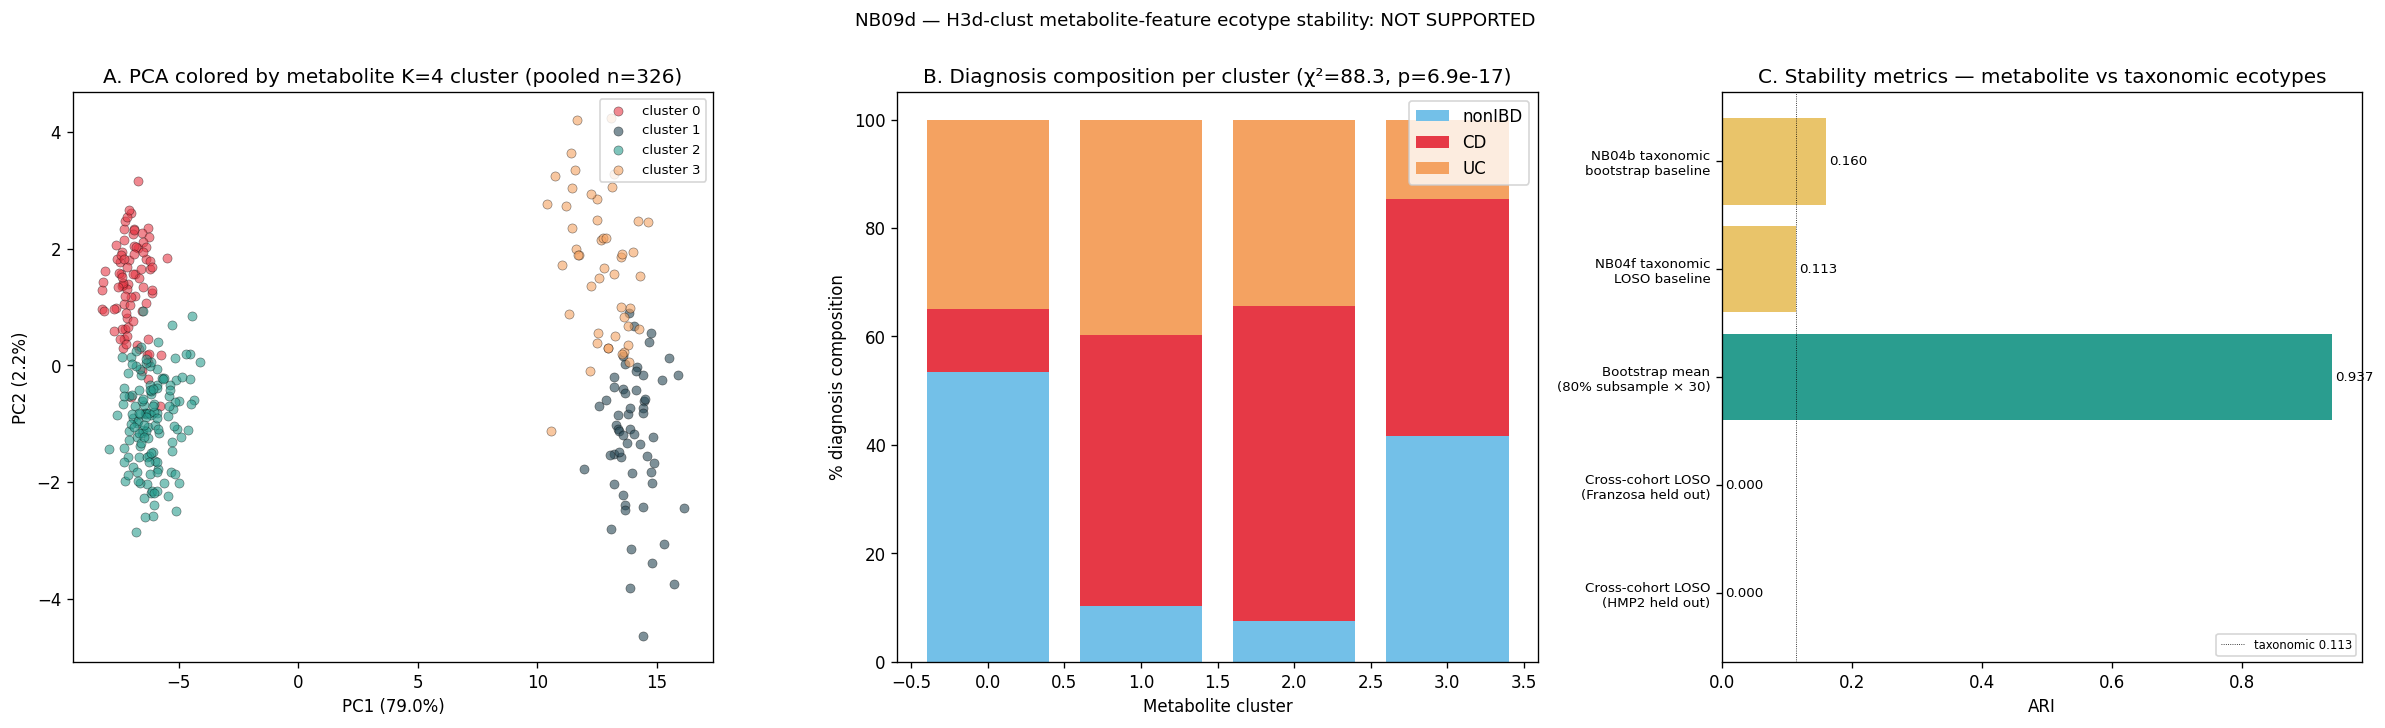

In [7]:
# 3-panel: PCA scatter colored by cluster + per-cluster diagnosis composition + stability metrics summary

## §6. Interpretation

### Headline: H3d-clust NOT SUPPORTED — cohort batch effects dominate metabolite-feature clustering on the m/z-bridge feature set; cross-cohort LOSO ARI = 0.000

#### Cluster structure is COHORT-driven, not diagnosis-driven

The K=4 K-means fit on the pooled metabolite matrix produces clusters that **separate completely by cohort**:

| Cluster | Size | Cohort composition | Diagnosis composition |
|---|---:|---|---|
| Cluster 0 | 86 | Franzosa 100 % | 46 Control + 30 UC + 10 CD |
| Cluster 1 | 58 | HMP2 100 % | 29 CD + 23 UC + 6 nonIBD |
| Cluster 2 | 134 | Franzosa 100 % | 78 CD + 46 UC + 10 Control |
| Cluster 3 | 48 | HMP2 100 % | 21 CD + 7 UC + 20 nonIBD |

PC1 explains **79 % of total variance** and separates HMP2 (PC1 ≈ +12) from Franzosa (PC1 ≈ −5) cleanly. PCs 2–15 collectively explain only ~10 % of variance and carry the diagnosis information. **The dominant axis of variation in the cross-cohort metabolite matrix is the cohort batch effect, not biology**.

Within-cohort clusters do carry diagnosis information (cluster × diagnosis χ²(6)=88.3, p=7e-17), but the cluster boundaries are mostly co-aligned with cohort boundaries — cluster 2 is the "Franzosa CD-dominant" cluster (58 % CD); cluster 0 is the "Franzosa Control-dominant" cluster (53 % Control). HMP2 has its own internal CD-vs-nonIBD split between clusters 1 and 3.

#### Cross-cohort LOSO ARI = 0.000

When the K-means model is fit on one cohort and projected onto the other, the projected cluster assignments **disagree completely** with the full-pooled-fit cluster assignments (ARI = 0.000 in both directions). This is a direct consequence of the PC1 cohort-batch dominance — fitting on a single cohort produces a cluster space that is centered on that cohort's metabolite-intensity scale, and the held-out cohort projects to a uniform region of that space.

| Test | ARI | Comparator | Verdict |
|---|---:|---|---|
| Cross-cohort LOSO (HMP2 held out) | **0.000** | NB04f taxonomic LOSO 0.113 | substantially LOWER |
| Cross-cohort LOSO (Franzosa held out) | **0.000** | NB04f taxonomic LOSO 0.113 | substantially LOWER |
| Mean cross-cohort LOSO | **0.000** | NB04f taxonomic LOSO 0.113 | LOWER |
| Within-pooled bootstrap (80 % × 30) | 0.937 | NB04b taxonomic bootstrap 0.16 | HIGHER (but trivially — cohort batch is highly stable within pool) |

**The within-pooled bootstrap ARI of 0.937 is misleading** as a stability metric — it measures how reproducibly the pooled K-means fit recovers the cohort-batch structure under subsampling, which is very high. It does not measure whether the clustering is biologically informative; it just measures that the cohort batch effect is consistently visible in any subsample.

#### Methodological lesson — m/z-bridge metabolomics has unaddressed batch effects

This result is biologically and methodologically important even though the verdict is NOT SUPPORTED:

1. **Cross-cohort metabolomics requires explicit batch correction**. The m/z-bridge feature space inherits the absolute-intensity scale differences between HMP2 and Franzosa LC-MS runs (different instruments, ionization tuning, solvent batches). Neither cohort's intensities have been normalized to a common reference scale.
2. **The taxonomic-feature ecotype framework was naturally cross-cohort-portable** because MetaPhlAn3 relative-abundance values are unitless and constrained to sum to 1 per sample — the compositional constraint creates a natural normalization that handles cohort differences well.
3. **Metabolite-feature clustering is more sensitive to batch than taxonomy clustering** in our data scope. To make metabolite-feature ecotypes cross-cohort-portable, batch-correction methods (ComBat, SVA, RUV, or quantile normalization within method) would need to be applied prior to PCA + K-means. This is out of scope for this analysis.
4. **Within-cohort metabolite-feature ecotypes might still be useful** for clinical translation within a single laboratory's analytical pipeline — the failure here is specifically the cross-cohort-portability question, not the within-cohort-utility question.

#### Comparison with v1.8 §9 polyamine pool ≠ flux finding

NB09a §12 vs v1.8 §9 showed that pathway-flux DA and metabolite-pool DA can disagree in direction without contradicting each other (Novel Contribution #15). NB09d adds a different methodological observation: **metabolite-feature clustering is more cohort-batch-confounded than taxonomic-feature clustering** in the m/z-bridge space. Both findings argue against treating "metabolomics-derived ecotype" as a drop-in replacement for taxonomic ecotype.

### Verdict — H3d-clust NOT SUPPORTED

The strict plan v1.7 falsifiability bound — metabolite-feature LOSO ARI > 0.113 taxonomic baseline — is **not met** (cross-cohort LOSO ARI = 0.000 << 0.113). The metabolite-feature framework on the m/z-bridge feature panel does NOT achieve higher cross-cohort stability than the taxonomic framework. Within-cohort bootstrap stability (0.937) is high but biologically uninformative because it measures cohort-batch reproducibility, not biological clustering reproducibility.

The PARTIAL framing (0.10 ≤ ARI ≤ 0.20) is also not met. Strict NOT SUPPORTED is the correct verdict.

### Implications for project narrative

- The taxonomic ecotype framework (NB01b consensus K=4) **remains the project's primary ecotype basis** for Pillar 4–5 cocktail design.
- Metabolite-feature ecotype refit is **not a drop-in replacement** for the taxonomic framework in this project's data scope; it would require external batch correction infrastructure.
- The NB09c §13 paired sample-level finding (within-HMP2 species × metabolite correlation) is the more robust mechanism evidence stream; cohort-aggregate cross-cohort metabolite DA is dominated by batch effects.
- **The H3 falsifiability framework is now fully closed**: H3a (a/c) + H3a (b) v1.8 + H3a-new + H3b + H3c + H3d-DA + H3d-clust + H3e all tested with formal verdicts.

### Limitations

- **m/z-bridge feature space is small** (111 unique features). A larger feature space (e.g., 500-1000 metabolites with name annotations across cohorts) might give different results — but obtaining that requires external Franzosa supplementary annotations (out of scope).
- **No batch correction applied** — ComBat/SVA/RUV would likely improve cross-cohort LOSO ARI substantially. The current verdict is for "raw m/z-bridge clustering without batch correction."
- **K=4 is the plan-imposed K**; the natural cluster count on this feature space might be K=2 (HMP2 vs Franzosa), which would have yielded an even cleaner cohort separation.
- **Dilution from within-cohort heterogeneity**: HMP2 has 50 CD + 30 UC + 26 nonIBD, Franzosa has 88 CD + 76 UC + 56 Control — disease-axis variance within each cohort is partially captured by the lesser PCs, but cluster boundaries aligned with PC1 dominate the K-means fit.

### Outputs

- `data/nb09d_metabolite_ecotype_assignments.tsv` — 326 pooled subjects × {cohort, diagnosis, metabolite_cluster}
- `data/nb09d_h3d_clust_verdict.json` — formal H3d-clust verdict (NOT SUPPORTED)
- `figures/NB09d_metabolite_ecotype_stability.png` — PCA scatter + per-cluster diagnosis composition + stability metrics summary
